In [1]:
import os
import sys
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdMolAlign

# 兼容：有些环境不会自动提供 exit
exit = sys.exit

# 兼容不同 RDKit 版本：确保 Chem.rdMolAlign 可用
Chem.rdMolAlign = rdMolAlign

## RDKit

In [2]:
data_id = 'apep_0'

db_name = 'apep'
root = f'./data_train/{db_name}/files'

mols_dir = 'mols'
mols_dir = os.path.join(root, mols_dir)
mol_path = os.path.join(mols_dir, f'{data_id}_mol.sdf')

proteins_dir = 'proteins'
protein_name_appendix = '_pro.pdb'
proteins_dir = os.path.join(root, proteins_dir)
protein_path = os.path.join(proteins_dir, data_id + protein_name_appendix)

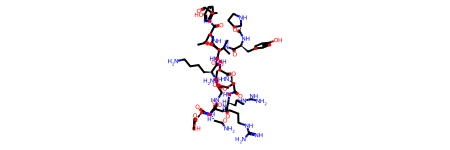

In [3]:
mol = Chem.MolFromMolFile(mol_path)
mol

In [4]:
mol.GetConformer().GetPositions()

array([[-1.2131e+01,  8.6970e+00, -3.0750e+00],
       [-1.2104e+01,  7.2950e+00, -2.6900e+00],
       [-1.2306e+01,  6.3620e+00, -3.8830e+00],
       [-1.3230e+01,  7.1270e+00, -1.6720e+00],
       [-1.3091e+01,  6.6480e+00, -4.7880e+00],
       [-1.4231e+01,  8.2150e+00, -2.0410e+00],
       [-1.3374e+01,  9.3240e+00, -2.6330e+00],
       [-1.1675e+01,  5.1900e+00, -3.8130e+00],
       [-1.2095e+01,  4.0240e+00, -4.5870e+00],
       [-1.3307e+01,  3.3970e+00, -3.8940e+00],
       [-1.0945e+01,  3.0150e+00, -4.6990e+00],
       [-1.3145e+01,  2.5770e+00, -2.9940e+00],
       [-9.7040e+00,  3.5410e+00, -5.3860e+00],
       [-9.7530e+00,  3.8930e+00, -6.7460e+00],
       [-8.4980e+00,  3.6630e+00, -4.6700e+00],
       [-8.6010e+00,  4.3730e+00, -7.3950e+00],
       [-7.3420e+00,  4.1400e+00, -5.3150e+00],
       [-6.2740e+00,  4.9360e+00, -7.3100e+00],
       [-7.3930e+00,  4.4940e+00, -6.6800e+00],
       [-1.4522e+01,  3.8240e+00, -4.2490e+00],
       [-1.5739e+01,  3.3230e+00, -3.585

In [5]:
mol.GetNumConformers()

1

In [1]:
# # from rdkit.Chem import rdMolAlign
from rdkit import Chem
from rdkit.Chem import AllChem

In [2]:
Chem.rdMolAlign

<module 'rdkit.Chem.rdMolAlign' from '/home/yangziqing/miniconda3/envs/pxm/lib/python3.8/site-packages/rdkit/Chem/rdMolAlign.so'>

In [3]:
atom_map = [[(i, i) for i in range(mol.GetNumAtoms())]]
rmsd = Chem.rdMolAlign.CalcRMS(mol, mol, map=atom_map)

NameError: name 'mol' is not defined

In [15]:
rmsd

0.0

### bond index

In [9]:
num_atoms = mol.GetNumAtoms()
num_bonds = mol.GetNumBonds()

conf = mol.GetConformer()
ele_list = []
pos_list = []
for i, atom in enumerate(mol.GetAtoms()):
    ele = atom.GetAtomicNum()
    pos = conf.GetAtomPosition(i)
    pos_list.append(list(pos))
    ele_list.append(ele)

In [10]:
row, col = [], []
bond_type = []
for bond in mol.GetBonds():
    b_type = int(bond.GetBondType())
    assert b_type in [1, 2, 3, 12], 'Bond can only be 1,2,3,12 bond'
    b_type = b_type if b_type != 12 else 4 # 12 -> 4, aromatic bond
    b_index = [
        bond.GetBeginAtomIdx(),
        bond.GetEndAtomIdx()
    ]
    bond_type += 2*[b_type]
    row += [b_index[0], b_index[1]]
    col += [b_index[1], b_index[0]]

bond_type = np.array(bond_type, dtype=np.int64)
bond_index = np.array([row, col],dtype=np.int64)

In [11]:
bond_index

array([[  1,   0,   1,   2,   3,   1,   4,   2,   5,   3,   6,   5,   6,
          0,   7,   2,   8,   7,   9,   8,   8,  10,  11,   9,  12,  10,
         13,  12,  14,  12,  15,  13,  16,  14,  18,  17,  18,  15,  18,
         16,  19,   9,  20,  19,  21,  20,  22,  20,  23,  21,  24,  22,
         25,  22,  26,  21,  27,  26,  28,  27,  27,  29,  30,  28,  31,
         29,  32,  31,  33,  31,  34,  28,  35,  34,  36,  35,  37,  35,
         38,  36,  37,  39,  40,  37,  41,  36,  42,  41,  43,  42,  42,
         44,  45,  43,  46,  44,  47,  46,  48,  47,  51,  48,  51,  50,
         51,  49,  52,  43,  53,  52,  54,  53,  53,  55,  56,  54,  57,
         55,  58,  57,  59,  58,  62,  60,  62,  59,  62,  61,  63,  54,
         64,  63,  65,  64,  64,  66,  67,  65,  68,  66,  69,  68,  70,
         68,  71,  65,  72,  71,  73,  72,  72,  74,  75,  73,  76,  74,
         77,  76,  78,  76,  79,  73,  80,  79,  81,  80,  80,  82,  83,
         81,  84,  81,  85,  84,  86,  85,  85,  87

In [12]:
perm = (bond_index[0] * num_atoms + bond_index[1]).argsort()
bond_index = bond_index[:, perm]
bond_type = bond_type[perm]

In [13]:
bond_index

array([[  0,   0,   1,   1,   1,   2,   2,   2,   3,   3,   4,   5,   5,
          6,   6,   7,   7,   8,   8,   8,   9,   9,   9,  10,  10,  11,
         12,  12,  12,  13,  13,  14,  14,  15,  15,  16,  16,  17,  18,
         18,  18,  19,  19,  20,  20,  20,  21,  21,  21,  22,  22,  22,
         23,  24,  25,  26,  26,  27,  27,  27,  28,  28,  28,  29,  29,
         30,  31,  31,  31,  32,  33,  34,  34,  35,  35,  35,  36,  36,
         36,  37,  37,  37,  38,  39,  40,  41,  41,  42,  42,  42,  43,
         43,  43,  44,  44,  45,  46,  46,  47,  47,  48,  48,  49,  50,
         51,  51,  51,  52,  52,  53,  53,  53,  54,  54,  54,  55,  55,
         56,  57,  57,  58,  58,  59,  59,  60,  61,  62,  62,  62,  63,
         63,  64,  64,  64,  65,  65,  65,  66,  66,  67,  68,  68,  68,
         69,  70,  71,  71,  72,  72,  72,  73,  73,  73,  74,  74,  75,
         76,  76,  76,  77,  78,  79,  79,  80,  80,  80,  81,  81,  81,
         82,  83,  84,  84,  85,  85,  85,  86,  86

In [14]:
[b_index[0], b_index[1]]

[119, 116]

In [15]:
bond_index[0] * num_atoms + bond_index[1]

array([    1,     6,   120,   122,   123,   241,   244,   247,   361,
         365,   482,   603,   606,   720,   725,   842,   848,   967,
         969,   970,  1088,  1091,  1099,  1208,  1212,  1329,  1450,
        1453,  1454,  1572,  1575,  1692,  1696,  1813,  1818,  1934,
        1938,  2058,  2175,  2176,  2177,  2289,  2300,  2419,  2421,
        2422,  2540,  2543,  2546,  2660,  2664,  2665,  2781,  2902,
        3022,  3141,  3147,  3266,  3268,  3269,  3387,  3390,  3394,
        3507,  3511,  3628,  3749,  3752,  3753,  3871,  3991,  4108,
        4115,  4234,  4236,  4237,  4355,  4358,  4361,  4475,  4479,
        4480,  4596,  4717,  4837,  4956,  4962,  5081,  5083,  5084,
        5202,  5205,  5212,  5322,  5326,  5443,  5564,  5567,  5686,
        5688,  5807,  5811,  5931,  6051,  6168,  6169,  6170,  6283,
        6293,  6412,  6414,  6415,  6533,  6536,  6543,  6653,  6657,
        6774,  6895,  6898,  7017,  7019,  7138,  7142,  7262,  7382,
        7499,  7500,

In [16]:
bond_index[1]

array([  1,   6,   0,   2,   3,   1,   4,   7,   1,   5,   2,   3,   6,
         0,   5,   2,   8,   7,   9,  10,   8,  11,  19,   8,  12,   9,
        10,  13,  14,  12,  15,  12,  16,  13,  18,  14,  18,  18,  15,
        16,  17,   9,  20,  19,  21,  22,  20,  23,  26,  20,  24,  25,
        21,  22,  22,  21,  27,  26,  28,  29,  27,  30,  34,  27,  31,
        28,  29,  32,  33,  31,  31,  28,  35,  34,  36,  37,  35,  38,
        41,  35,  39,  40,  36,  37,  37,  36,  42,  41,  43,  44,  42,
        45,  52,  42,  46,  43,  44,  47,  46,  48,  47,  51,  51,  51,
        48,  49,  50,  43,  53,  52,  54,  55,  53,  56,  63,  53,  57,
        54,  55,  58,  57,  59,  58,  62,  62,  62,  59,  60,  61,  54,
        64,  63,  65,  66,  64,  67,  71,  64,  68,  65,  66,  69,  70,
        68,  68,  65,  72,  71,  73,  74,  72,  75,  79,  72,  76,  73,
        74,  77,  78,  76,  76,  73,  80,  79,  81,  82,  80,  83,  84,
        80,  81,  81,  85,  84,  86,  87,  85,  88,  93,  85,  8

### rotable bond

In [17]:
mol = Chem.MolFromMolFile('data_train/bpep/files/mols/bpep_8pp0_mol.sdf')
mol.GetNumAtoms()

106

In [18]:
from rdkit.Chem.Lipinski import RotatableBondSmarts

rot_atom_pairs = mol.GetSubstructMatches(RotatableBondSmarts)

rot_mat = np.zeros((mol.GetNumAtoms(), mol.GetNumAtoms()), dtype=int)
for i, j in rot_atom_pairs:
    rot_mat[i, j] = 1
    rot_mat[j, i] = 1

In [19]:
rot_mat

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [20]:
from utils.parser import parse_3d_mol
bond_index = parse_3d_mol(mol)['bond_index']

In [21]:
bond_rotatable = rot_mat[bond_index[0], bond_index[1]]
rotatable_bond_index = bond_index[:, bond_rotatable==1]

In [22]:
import networkx as nx
G_base = nx.from_edgelist(bond_index.T)

In [23]:
G_base.edges()

EdgeView([(0, 1), (1, 2), (1, 4), (2, 3), (2, 5), (5, 6), (6, 7), (6, 9), (7, 8), (7, 15), (9, 10), (15, 16), (10, 11), (10, 12), (11, 13), (12, 14), (13, 14), (16, 17), (16, 19), (17, 18), (17, 24), (19, 20), (24, 25), (20, 21), (21, 22), (22, 23), (25, 26), (25, 28), (26, 27), (26, 32), (28, 29), (28, 30), (32, 33), (29, 31), (33, 34), (33, 36), (34, 35), (34, 40), (36, 37), (40, 41), (37, 38), (37, 39), (41, 42), (41, 44), (42, 43), (42, 50), (44, 45), (50, 51), (45, 46), (45, 47), (46, 48), (47, 49), (48, 49), (51, 52), (51, 54), (52, 53), (52, 61), (54, 55), (61, 62), (55, 56), (56, 57), (57, 58), (58, 59), (58, 60), (62, 63), (62, 65), (63, 64), (63, 69), (65, 66), (69, 70), (66, 67), (66, 68), (70, 71), (70, 73), (71, 72), (71, 77), (73, 74), (77, 78), (74, 75), (74, 76), (78, 79), (78, 81), (79, 80), (79, 86), (81, 82), (86, 87), (82, 83), (83, 84), (83, 85), (87, 88), (87, 90), (88, 89), (88, 94), (90, 91), (94, 95), (91, 92), (91, 93), (95, 96), (95, 98), (96, 97), (96, 100),

In [24]:
path_mat = Chem.GetDistanceMatrix(mol)

In [25]:
path_mat

array([[ 0.,  1.,  2., ..., 39., 38., 39.],
       [ 1.,  0.,  1., ..., 38., 37., 38.],
       [ 2.,  1.,  0., ..., 37., 36., 37.],
       ...,
       [39., 38., 37., ...,  0.,  3.,  4.],
       [38., 37., 36., ...,  3.,  0.,  1.],
       [39., 38., 37., ...,  4.,  1.,  0.]])

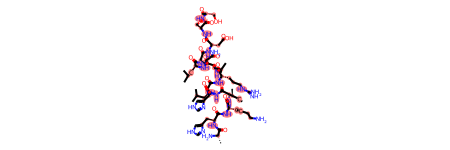

In [26]:
mol

In [46]:
isomeric = False
matches = np.array(mol.GetSubstructMatches(mol, uniquify=False, useChirality=isomeric, maxMatches=10000))

In [51]:
matches[0]

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119])

In [52]:
matches[1]

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 115, 114, 117,
       116, 118, 119])

In [49]:
n_atoms = mol.GetNumAtoms()
natural_order = np.arange(n_atoms)
is_natural = (matches == natural_order).all(-1)

In [53]:
inconsistent = (matches != matches[is_natural]).any(axis=0)

In [56]:
(matches != matches[is_natural]).any(axis=0)

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True,  True,  True,  True, False,
       False, False, False, False, False, False,  True,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
        True, False, False, False, False, False, False,  True,  True,
       False, False, False, False, False, False,  True,  True,  True,
        True, False, False])

In [ ]:
(matches == natural_order).all(-1)

array([ True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False])

In [64]:
(matches != matches[is_natural]).any(0)

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True,  True,  True,  True, False,
       False, False, False, False, False, False,  True,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
        True, False, False, False, False, False, False,  True,  True,
       False, False, False, False, False, False,  True,  True,  True,
        True, False, False])

In [36]:
rot_mat[bond_index[0], bond_index[1]]

array([0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0])

## PDB

In [6]:
line = 'ATOM    467  N   LEU A 589      19.072  -3.082  61.759  1.00 52.23           N'
line[13:14]

'N'

In [8]:
{
                    'line': line,
                    'type': 'ATOM',
                    'atom_id': int(line[6:11]),
                    'atom_name': line[12:16].strip(),
                    'res_name': line[17:20].strip(),
                    'chain': line[21:22].strip(),
                    'res_id': int(line[22:26]),
                    'res_insert_id': line[26:27].strip(),
                    'x': float(line[30:38]),
                    'y': float(line[38:46]),
                    'z': float(line[46:54]),
                    'occupancy': float(line[54:60]),
                    'segment': line[72:76].strip(),
                    'charge': line[78:80].strip(),
                }

{'line': 'ATOM    467  N   LEU A 589      19.072  -3.082  61.759  1.00 52.23           N',
 'type': 'ATOM',
 'atom_id': 467,
 'atom_name': 'N',
 'res_name': 'LEU',
 'chain': 'A',
 'res_id': 589,
 'res_insert_id': '',
 'x': 19.072,
 'y': -3.082,
 'z': 61.759,
 'occupancy': 1.0,
 'segment': '',
 'charge': ''}

In [66]:
print(Chem.GetPeriodicTable().GetAtomicNumber('H'))
print(Chem.GetPeriodicTable().GetAtomicNumber('C'))

1
6


In [68]:
from rdkit.Chem.BRICS import FindBRICSBonds

In [71]:
[bond for bond in FindBRICSBonds(mol)]

[((2, 7), ('1', '5')),
 ((9, 19), ('1', '5')),
 ((21, 26), ('1', '5')),
 ((28, 34), ('1', '5')),
 ((36, 41), ('1', '5')),
 ((43, 52), ('1', '5')),
 ((54, 63), ('1', '5')),
 ((65, 71), ('1', '5')),
 ((73, 79), ('1', '5')),
 ((81, 84), ('1', '5')),
 ((86, 93), ('1', '5')),
 ((95, 100), ('1', '5')),
 ((102, 108), ('1', '5')),
 ((8, 7), ('4', '5')),
 ((20, 19), ('4', '5')),
 ((27, 26), ('4', '5')),
 ((35, 34), ('4', '5')),
 ((42, 41), ('4', '5')),
 ((47, 48), ('4', '5')),
 ((53, 52), ('4', '5')),
 ((58, 59), ('4', '5')),
 ((64, 63), ('4', '5')),
 ((72, 71), ('4', '5')),
 ((80, 79), ('4', '5')),
 ((85, 84), ('4', '5')),
 ((94, 93), ('4', '5')),
 ((101, 100), ('4', '5')),
 ((109, 108), ('4', '5')),
 ((2, 1), ('6', '13')),
 ((10, 12), ('8', '16')),
 ((111, 113), ('8', '16'))]

In [72]:
pattern = Chem.MolFromSmarts('[#6+0;!$(*=,#[!#6])]!@!=!#[*]')

find_bonds =mol.GetSubstructMatches(pattern)

In [75]:
sum([[1,2,3], [4,5,6]], [])

[1, 2, 3, 4, 5, 6]

## Parse peptide

In [29]:
import numpy as np
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1
from utils.parser import PDBProtein

pdb_path = 'data_tmp/bpep_8ahy_P_pep.pdb'

In [30]:
parser = PDBParser(PERMISSIVE=0)
structure = parser.get_structure('structure', pdb_path)

pep_feature_dict = {'pos': [], 'atom_name': [], 'is_backbone': [], 'res_id': [], 'atom_to_aa_type': []}
for atom in structure.get_atoms():
    element = atom.element
    if element == 'H':
        continue
    element = element if len(element) == 1 else element[0] + element[1].lower()
    pep_feature_dict['pos'].append(atom.get_coord())
    pep_feature_dict['atom_name'].append(atom.get_name())
    res = atom.get_parent()
    pep_feature_dict['res_id'].append(res.get_id()[1])
    resname = res.get_resname()
    aa_type = PDBProtein.AA_NAME_NUMBER[resname] if resname in PDBProtein.AA_NAME_NUMBER else len(PDBProtein.AA_NAME_NUMBER)
    pep_feature_dict['atom_to_aa_type'].append(aa_type)
    pep_feature_dict['is_backbone'].append(
        (atom.get_name() in PDBProtein.BACKBONE_NAMES) and (aa_type < len(PDBProtein.AA_NAME_NUMBER)))

unique_res_id, res_index = np.unique(pep_feature_dict['res_id'], return_inverse=True)
pep_feature_dict['res_index'] = res_index
assert (np.diff(unique_res_id) == 1).all(), 'residue id is not continuous'

pep_feature_dict = {k: np.array(v) for k, v in pep_feature_dict.items()}

pep_feature_dict['seq'] = ''.join([seq1(residue.get_resname()) or 'X' for residue in structure.get_residues()])
pep_feature_dict['pep_len'] = len(pep_feature_dict['seq'])
pep_feature_dict['pep_path'] = pdb_path
pep_feature_dict['atom_name'] = list(pep_feature_dict['atom_name'])

if 'X' in pep_feature_dict['seq']:
    print('Warning: X in peptide sequence:', pdb_path)

In [31]:
pep_feature_dict

{'pos': array([[-16.602,  -1.746,  27.269],
        [-16.584,  -0.501,  26.505],
        [-15.205,  -0.262,  25.863],
        [-14.199,  -0.872,  26.257],
        [-16.981,   0.659,  27.403],
        [-16.353,   1.85 ,  26.984],
        [-15.167,   0.653,  24.895],
        [-13.966,   0.958,  24.121],
        [-13.864,   2.469,  24.113],
        [-14.899,   3.145,  24.023],
        [-14.063,   0.478,  22.669],
        [-12.89 ,   0.919,  21.813],
        [-14.12 ,  -0.912,  22.643],
        [-12.682,   3.052,  24.12 ],
        [-12.624,   4.51 ,  24.031],
        [-13.437,   5.062,  22.861],
        [-13.442,   4.525,  21.76 ],
        [-11.132,   4.791,  23.873],
        [-10.444,   3.657,  24.563],
        [-11.349,   2.445,  24.302],
        [-14.127,   6.171,  23.099],
        [-15.093,   6.647,  22.113],
        [-14.436,   6.915,  20.765],
        [-14.995,   6.572,  19.719],
        [-15.801,   7.921,  22.615],
        [-17.238,   8.137,  22.029],
        [-18.305,   7.226,  22.

## sample_pdb.py

In [1]:
from utils.misc import *

/home/yangziqing/miniconda3/envs/pxm/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
config_task = 'configs/sample/test/pepdesign_pepbdb/base.yml'
config_model = 'configs/sample/pxm.yml'
config_train = 'data/trained_models/pxm/train_config/train.yml'

In [7]:
config = make_config(config_task, config_model)
if config_model is not None:
    config_name = os.path.basename(config_task).replace('.yml', '') 
    config_name += '_' + os.path.basename(config_model).replace('.yml', '')

In [8]:
train_config = make_config(config_train)

In [9]:
config.get('transforms', {})

{}

In [48]:
train_config.get('transforms', {}).keys()

dict_keys(['featurizer', 'featurizer_pocket', 'task'])

## LMDB - Benchmark

In [2]:
from utils.dataset import LMDBDatabase

In [4]:
lmdb_path = f'data/test/assemblies/lmdb/dock_pepbdb_test.lmdb'
pep_lmdb_path = f'data/pepbdb/lmdb/peptide.lmdb'
pro_lmdb_path = f'data/pepbdb/lmdb/pocmol10.lmdb'

db = LMDBDatabase(lmdb_path, readonly=True)
pep_db = LMDBDatabase(pep_lmdb_path, readonly=True)
pro_db = LMDBDatabase(pro_lmdb_path, readonly=True)

print(len(db))
print(db.get_all_keys())

print(len(pep_db))
print(pep_db.get_all_keys())

print(len(pro_db))
print(pro_db.get_all_keys())

84
['datatask_dbs', 'dock-pepbdb', 'dock-pepbdb-0', 'dock-pepbdb-1', 'dock-pepbdb-10', 'dock-pepbdb-11', 'dock-pepbdb-12', 'dock-pepbdb-13', 'dock-pepbdb-14', 'dock-pepbdb-15', 'dock-pepbdb-16', 'dock-pepbdb-17', 'dock-pepbdb-18', 'dock-pepbdb-19', 'dock-pepbdb-2', 'dock-pepbdb-20', 'dock-pepbdb-21', 'dock-pepbdb-22', 'dock-pepbdb-23', 'dock-pepbdb-24', 'dock-pepbdb-25', 'dock-pepbdb-26', 'dock-pepbdb-27', 'dock-pepbdb-28', 'dock-pepbdb-29', 'dock-pepbdb-3', 'dock-pepbdb-30', 'dock-pepbdb-31', 'dock-pepbdb-32', 'dock-pepbdb-33', 'dock-pepbdb-34', 'dock-pepbdb-35', 'dock-pepbdb-36', 'dock-pepbdb-37', 'dock-pepbdb-38', 'dock-pepbdb-39', 'dock-pepbdb-4', 'dock-pepbdb-40', 'dock-pepbdb-41', 'dock-pepbdb-42', 'dock-pepbdb-43', 'dock-pepbdb-44', 'dock-pepbdb-45', 'dock-pepbdb-46', 'dock-pepbdb-47', 'dock-pepbdb-48', 'dock-pepbdb-49', 'dock-pepbdb-5', 'dock-pepbdb-50', 'dock-pepbdb-51', 'dock-pepbdb-52', 'dock-pepbdb-53', 'dock-pepbdb-54', 'dock-pepbdb-55', 'dock-pepbdb-56', 'dock-pepbdb-57',

In [2]:
pep_train_lmdb_path = f'data_train/bpep/lmdb/peptide.lmdb'
pep_train_db = LMDBDatabase(pep_train_lmdb_path, readonly=True)
print(len(pep_train_db))
print(pep_train_db.get_all_keys())

101
['bpep_7prx', 'bpep_7qwv', 'bpep_7sxf', 'bpep_7sxh', 'bpep_7tmy', 'bpep_7trl', 'bpep_7udj', 'bpep_7udk', 'bpep_7ue2', 'bpep_7umi', 'bpep_7uw2', 'bpep_7wqq', 'bpep_7xfg', 'bpep_7xv0', 'bpep_7xv4', 'bpep_7yod', 'bpep_7yoh', 'bpep_7yue', 'bpep_7z6f', 'bpep_7z6u', 'bpep_8ael', 'bpep_8afr', 'bpep_8are', 'bpep_8b0p', 'bpep_8b9t', 'bpep_8bft', 'bpep_8bia', 'bpep_8brh', 'bpep_8bva', 'bpep_8by5', 'bpep_8c1j', 'bpep_8c2p', 'bpep_8cd3', 'bpep_8ck5', 'bpep_8cqy', 'bpep_8dk4', 'bpep_8dvl', 'bpep_8dzv', 'bpep_8ens', 'bpep_8eq5', 'bpep_8ese', 'bpep_8exj', 'bpep_8exk', 'bpep_8exm', 'bpep_8f8m', 'bpep_8fg6', 'bpep_8fub', 'bpep_8gl7', 'bpep_8gqa', 'bpep_8h7k', 'bpep_8hep', 'bpep_8heq', 'bpep_8her', 'bpep_8hlo', 'bpep_8hlw', 'bpep_8hmx', 'bpep_8hqt', 'bpep_8hz8', 'bpep_8ia5', 'bpep_8in0', 'bpep_8j5u', 'bpep_8jjv', 'bpep_8jpf', 'bpep_8kdx', 'bpep_8okf', 'bpep_8op0', 'bpep_8opi', 'bpep_8pdp', 'bpep_8pii', 'bpep_8pp0', 'bpep_8q5p', 'bpep_8q7i', 'bpep_8qci', 'bpep_8qfz', 'bpep_8qu9', 'bpep_8r10', 'bpep_8

In [5]:
pep_lmdb_path = f'data/pepbdb/lmdb/peptide.lmdb'
pro_lmdb_path = f'data/pepbdb/lmdb/pocmol10.lmdb'

pep_db = LMDBDatabase(pep_lmdb_path, readonly=True)
pro_db = LMDBDatabase(pro_lmdb_path, readonly=True)

print(len(db))
print(db.get_all_keys())

print(len(pep_db))
print(pep_db.get_all_keys())

print(len(pro_db))
print(pro_db.get_all_keys())

84
['datatask_dbs', 'dock-pepbdb', 'dock-pepbdb-0', 'dock-pepbdb-1', 'dock-pepbdb-10', 'dock-pepbdb-11', 'dock-pepbdb-12', 'dock-pepbdb-13', 'dock-pepbdb-14', 'dock-pepbdb-15', 'dock-pepbdb-16', 'dock-pepbdb-17', 'dock-pepbdb-18', 'dock-pepbdb-19', 'dock-pepbdb-2', 'dock-pepbdb-20', 'dock-pepbdb-21', 'dock-pepbdb-22', 'dock-pepbdb-23', 'dock-pepbdb-24', 'dock-pepbdb-25', 'dock-pepbdb-26', 'dock-pepbdb-27', 'dock-pepbdb-28', 'dock-pepbdb-29', 'dock-pepbdb-3', 'dock-pepbdb-30', 'dock-pepbdb-31', 'dock-pepbdb-32', 'dock-pepbdb-33', 'dock-pepbdb-34', 'dock-pepbdb-35', 'dock-pepbdb-36', 'dock-pepbdb-37', 'dock-pepbdb-38', 'dock-pepbdb-39', 'dock-pepbdb-4', 'dock-pepbdb-40', 'dock-pepbdb-41', 'dock-pepbdb-42', 'dock-pepbdb-43', 'dock-pepbdb-44', 'dock-pepbdb-45', 'dock-pepbdb-46', 'dock-pepbdb-47', 'dock-pepbdb-48', 'dock-pepbdb-49', 'dock-pepbdb-5', 'dock-pepbdb-50', 'dock-pepbdb-51', 'dock-pepbdb-52', 'dock-pepbdb-53', 'dock-pepbdb-54', 'dock-pepbdb-55', 'dock-pepbdb-56', 'dock-pepbdb-57',

## Metrics

In [121]:
import os
import argparse
import numpy as np
import pandas as pd
import subprocess
from tqdm import tqdm
import re

import sys
sys.path.append('.')
from evaluate.evaluate_mols import get_dir_from_prefix

PATH_TMALIGN = '/home/yangziqing/software/TMalign'
assert PATH_TMALIGN is not None, "Please set PATH_TMALIGN to your TMalign installation path."

def get_tmscore(pep_pred_path, pep_gt_path, task=None):
    """
    Calculate TM-score for peptide docking results
    """
    cmd = [f'{PATH_TMALIGN}/TMalign', pep_pred_path, pep_gt_path] # default for task = 'pepdesign' (inverse folding)
    
    if task == 'dock':
        cmd += ['-byresi', '1', '-het', '1'] # align by residue index; include hetero atoms
    elif task == 'pepdesign':
        cmd += ['-het', '1']
    
    output = subprocess.run(cmd, capture_output=True, text=True)
    if output.returncode != 0:
        raise ValueError('TM-align errored:' + output.stderr)
    
    results = output.stdout.split('\n')
    print(output.stdout)

    rmsd_ca_ba = np.nan
    tm_scores = np.nan
    
    for line in results:
        if line.startswith('Aligned length') and 'RMSD' in line:
            rmsd_ca_ba = float(re.search(r"RMSD=\s*([\d.]+)", line).group(1))
        if line.startswith('TM-score') and 'Chain_2' in line:
            tm_scores = float(re.search(r"TM-score=\s*([\d.]+)", line).group(1)) # normalized by Chain_2 (native.pdb)
    return {
        'tmscore': tm_scores,
        'rmsd_ca_ba': rmsd_ca_ba
    }

In [126]:
# test 1
# pep_pred_path = 'outputs_test/dock_bpep/base_pxm_20260318_165320/SDF/5.pdb'
# pep_gt_path = 'outputs_test/dock_bpep/base_pxm_20260318_165320/SDF/5_gt.pdb'

# test 2
pep_pred_path = 'outputs_test/dock_cpep/base_pxm_20260318_170001/SDF/0-nonstd.pdb'
pep_gt_path = 'outputs_test/dock_cpep/base_pxm_20260318_170001/SDF/0-nonstd_gt.pdb'

In [127]:
result_dock = get_tmscore(pep_pred_path, pep_gt_path, task='dock')
print(result_dock)


 *********************************************************************
 * TM-align (Version 20220412): protein structure alignment          *
 * References: Y Zhang, J Skolnick. Nucl Acids Res 33, 2302-9 (2005) *
 * Please email comments and suggestions to zhanglab@zhanggroup.org   *
 *********************************************************************

Name of Chain_1: outputs_test/dock_cpep/base_pxm_20260318_170001/SDF/0-nonstd.pdb (to be superimposed onto Chain_2)
Name of Chain_2: outputs_test/dock_cpep/base_pxm_20260318_170001/SDF/0-nonstd_gt.pdb
Length of Chain_1: 16 residues
Length of Chain_2: 16 residues

User-specified initial alignment: TM/Lali/rmsd = 0.18705,   16,  8.093
Aligned length= 16, RMSD=   8.09, Seq_ID=n_identical/n_aligned= 1.000
TM-score= 0.16096 (if normalized by length of Chain_1, i.e., LN=16, d0=0.50)
TM-score= 0.16096 (if normalized by length of Chain_2, i.e., LN=16, d0=0.50)
(You should use TM-score normalized by length of the reference structure)

(":" den

In [128]:
results = get_tmscore(pep_pred_path, pep_gt_path, task='pepdesign')
print(results)


 *********************************************************************
 * TM-align (Version 20220412): protein structure alignment          *
 * References: Y Zhang, J Skolnick. Nucl Acids Res 33, 2302-9 (2005) *
 * Please email comments and suggestions to zhanglab@zhanggroup.org   *
 *********************************************************************

Name of Chain_1: outputs_test/dock_cpep/base_pxm_20260318_170001/SDF/0-nonstd.pdb (to be superimposed onto Chain_2)
Name of Chain_2: outputs_test/dock_cpep/base_pxm_20260318_170001/SDF/0-nonstd_gt.pdb
Length of Chain_1: 16 residues
Length of Chain_2: 16 residues

Aligned length= 10, RMSD=   2.17, Seq_ID=n_identical/n_aligned= 0.000
TM-score= 0.14875 (if normalized by length of Chain_1, i.e., LN=16, d0=0.50)
TM-score= 0.14875 (if normalized by length of Chain_2, i.e., LN=16, d0=0.50)
(You should use TM-score normalized by length of the reference structure)

(":" denotes residue pairs of d <  5.0 Angstrom, "." denotes other aligned resi

In [129]:
results = get_tmscore(pep_pred_path, pep_gt_path, task=None)
print(results)


 *********************************************************************
 * TM-align (Version 20220412): protein structure alignment          *
 * References: Y Zhang, J Skolnick. Nucl Acids Res 33, 2302-9 (2005) *
 * Please email comments and suggestions to zhanglab@zhanggroup.org   *
 *********************************************************************

Name of Chain_1: outputs_test/dock_cpep/base_pxm_20260318_170001/SDF/0-nonstd.pdb (to be superimposed onto Chain_2)
Name of Chain_2: outputs_test/dock_cpep/base_pxm_20260318_170001/SDF/0-nonstd_gt.pdb
Length of Chain_1: 15 residues
Length of Chain_2: 15 residues

Aligned length= 7, RMSD=   2.48, Seq_ID=n_identical/n_aligned= 0.000
TM-score= 0.15581 (if normalized by length of Chain_1, i.e., LN=15, d0=0.50)
TM-score= 0.15581 (if normalized by length of Chain_2, i.e., LN=15, d0=0.50)
(You should use TM-score normalized by length of the reference structure)

(":" denotes residue pairs of d <  5.0 Angstrom, "." denotes other aligned resid

In [120]:
def get_ca_atoms(structure, chain_id=None):
    """
    从 Bio.PDB Structure 中取出 CA 原子坐标与列表
    每个residue中只有一个 CA 原子, 因此只需保证pred.pdb和gt.pdb的residue顺序一致即可
    """
    ca_list = []
    for model in structure:
        for chain in model:
            if chain_id is not None and chain.id != chain_id:
                continue
            for res in chain:
                # print(res)
                # print(res.id[1])
                if res.id[1] == 4:
                    for atom in res:
                        print(atom, atom.get_coord())
                if "CA" in res:
                    ca_list.append(res["CA"])
            if chain_id is not None: # chain_id = None: extract all chains
                break
        break # only extract the first model
    return ca_list

path_1 = 'data_train/cpep/files/peptides/cpep_8ibo_pep.pdb'
parser = PDBParser(QUIET=True)
s_gt = parser.get_structure("gt", path_1)
ca_gt = get_ca_atoms(s_gt)

<DisorderedAtom N> [-33.265 -17.031   9.029]
<DisorderedAtom CA> [-32.702 -18.391   8.909]
<DisorderedAtom C> [-33.099 -19.264   7.713]
<DisorderedAtom O> [-32.239 -19.978   7.176]
<DisorderedAtom CB> [-32.972 -19.168  10.203]
<DisorderedAtom CG> [-32.844 -18.338  11.482]
<DisorderedAtom CD> [-31.428 -18.281  12.029]
<DisorderedAtom NE> [-31.19  -17.194  12.985]
<DisorderedAtom CZ> [-29.982 -16.757  13.312]
<DisorderedAtom NH1> [-29.837 -15.76   14.177]
<DisorderedAtom NH2> [-28.912 -17.304  12.761]


In [108]:
len(ca_gt)

16

### pepbdb

In [62]:
path_pepbdb_info = 'outputs_test/pepinv_pepbdb/base_pxm_20260319_163803/rmsd_ca_pdb.csv'
df_pepbdb_info = pd.read_csv(path_pepbdb_info)
df_pepbdb_info['error'] = df_pepbdb_info['error_code'].apply(lambda x: x.split(':')[0].strip() if isinstance(x, str) else 'success')
print(df_pepbdb_info['error'].value_counts())

success                            5361
mismatched num of CA atoms         1397
no CA atoms found in pred or gt     242
Name: error, dtype: int64


In [63]:
# tag标记为nan: 均能正常计算CA-RMSD
print(df_pepbdb_info[df_pepbdb_info['tag'].isna()]['error'].value_counts())

success    5325
Name: error, dtype: int64


In [64]:
# tag标记为bad: 均不能正常计算CA-RMSD
# tag标记为nonstd: 部分能正常计算CA-RMSD
# tag标记为incomp: 部分能正常计算CA-RMSD
print('Total:')
print(df_pepbdb_info[~df_pepbdb_info['tag'].isna()]['error'].value_counts())

print('\nbad:')
print(df_pepbdb_info[df_pepbdb_info['tag']=='bad']['error'].value_counts())
print('\nnonstd:')
print(df_pepbdb_info[df_pepbdb_info['tag']=='nonstd']['error'].value_counts())
print('\nincomp:')
print(df_pepbdb_info[df_pepbdb_info['tag']=='incomp']['error'].value_counts())

Total:
mismatched num of CA atoms         1397
no CA atoms found in pred or gt     242
success                              36
Name: error, dtype: int64

bad:
no CA atoms found in pred or gt    240
Name: error, dtype: int64

nonstd:
mismatched num of CA atoms         1385
success                               3
no CA atoms found in pred or gt       2
Name: error, dtype: int64

incomp:
success                       33
mismatched num of CA atoms    12
Name: error, dtype: int64


### bpep

In [65]:
path_bpep_info = 'outputs_test/pepinv_bpep/base_pxm_20260319_115259/rmsd_ca_pdb.csv'
df_bpep_info = pd.read_csv(path_bpep_info)
df_bpep_info['error'] = df_bpep_info['error_code'].apply(lambda x: x.split(':')[0].strip() if isinstance(x, str) else 'success')
print(df_bpep_info['error'].value_counts())

success                            15131
mismatched num of CA atoms          4556
no CA atoms found in pred or gt      713
Name: error, dtype: int64


In [66]:
# tag标记为nan: 均能正常计算CA-RMSD
print(df_bpep_info[df_bpep_info['tag'].isna()]['error'].value_counts())

success    15037
Name: error, dtype: int64


In [67]:
# tag标记为bad (sdf转换pdb失败, pdb为空): 均不能正常计算CA-RMSD
# tag标记为nonstd (含有non-standard residue): 部分能正常计算CA-RMSD
# tag标记为incomp: 部分能正常计算CA-RMSD
print('Total:')
print(df_bpep_info[~df_bpep_info['tag'].isna()]['error'].value_counts())

print('\nbad:')
print(df_bpep_info[df_bpep_info['tag']=='bad']['error'].value_counts())
print('\nnonstd:')
print(df_bpep_info[df_bpep_info['tag']=='nonstd']['error'].value_counts())
print('\nincomp:')
print(df_bpep_info[df_bpep_info['tag']=='incomp']['error'].value_counts())

Total:
mismatched num of CA atoms         4556
no CA atoms found in pred or gt     713
success                              94
Name: error, dtype: int64

bad:
no CA atoms found in pred or gt    710
Name: error, dtype: int64

nonstd:
mismatched num of CA atoms         4523
success                              12
no CA atoms found in pred or gt       3
Name: error, dtype: int64

incomp:
success                       82
mismatched num of CA atoms    33
Name: error, dtype: int64


In [68]:
df_bpep_info[df_bpep_info['tag'].isna()].head()

,data_id,db,task,key,aaseq,smiles,tag,filename,i_repeat,cfd_traj,cfd_pos,cfd_node,cfd_edge,rmsd_ca_ta,rmsd_ca_ba,error_code,error
0,bpep_8pp0,bpep,pepdesign,pocmol10/bpep_8pp0;peptide/bpep_8pp0,RTELLDELLTKTA,CC(C)CC(NC(=O)C(CC(C)C)NC(=O)C(CCC(=O)O)NC(=O)...,NaN,0.pdb,0,1.450050,2.427882,15.717711,21.538177,0.0,2.800553e-15,NaN,success
1,bpep_8tgp,bpep,pepdesign,pocmol10/bpep_8tgp;peptide/bpep_8tgp,SPRVV,CC(C)C(C=O)NC(=O)C(NC(=O)C(CCCNC(=N)N)NC(=O)C1...,NaN,1.pdb,0,1.610464,2.497472,16.436626,20.604713,0.0,2.184630e-15,NaN,success
2,bpep_8wxt,bpep,pepdesign,pocmol10/bpep_8wxt;peptide/bpep_8wxt,GSQKNKGFE,NCCCCC(NC(=O)C(CC(N)=O)NC(=O)C(CCCCN)NC(=O)C(C...,NaN,2.pdb,0,1.554459,2.536185,16.488947,21.402365,0.0,2.765424e-15,NaN,success
5,bpep_7uw2,bpep,pepdesign,pocmol10/bpep_7uw2;peptide/bpep_7uw2,ARLIKFLLLV,CCC(C)C(NC(=O)C(CC(C)C)NC(=O)C(CCCNC(=N)N)NC(=...,NaN,5.pdb,0,1.482711,2.479719,15.687031,21.073046,0.0,2.808667e-16,NaN,success
6,bpep_8bia,bpep,pepdesign,pocmol10/bpep_8bia;peptide/bpep_8bia,TSEETTAL,CC(C)CC(C=O)NC(=O)C(C)NC(=O)C(NC(=O)C(NC(=O)C(...,NaN,6.pdb,0,1.704524,2.488784,16.986439,21.723470,0.0,4.442280e-15,NaN,success


### cpep

In [56]:
path_cpep_info = 'outputs_test/pepinv_cpep/base_pxm_20260320_223246/rmsd_ca_pdb.csv'
df_cpep_info = pd.read_csv(path_cpep_info)
df_cpep_info['error'] = df_cpep_info['error_code'].apply(lambda x: x.split(':')[0].strip() if isinstance(x, str) else 'success')
print(df_cpep_info['error'].value_counts())

mismatched num of CA atoms         2344
success                            1830
no CA atoms found in pred or gt    1626
Name: error, dtype: int64


In [57]:
# tag标记为nan: 均能正常计算CA-RMSD
print(df_cpep_info[df_cpep_info['tag'].isna()]['error'].value_counts())

success                       1404
mismatched num of CA atoms     225
Name: error, dtype: int64


In [58]:
# tag标记为bad (sdf转换pdb失败, pdb为空): 均不能正常计算CA-RMSD
# tag标记为nonstd (含有non-standard residue): 部分能正常计算CA-RMSD
# tag标记为incomp: 部分能正常计算CA-RMSD
print('Total:')
print(df_cpep_info[~df_cpep_info['tag'].isna()]['error'].value_counts())

print('\nbad:')
print(df_cpep_info[df_cpep_info['tag']=='bad']['error'].value_counts())
print('\nnonstd:')
print(df_cpep_info[df_cpep_info['tag']=='nonstd']['error'].value_counts())
print('\nincomp:')
print(df_cpep_info[df_cpep_info['tag']=='incomp']['error'].value_counts())

Total:
mismatched num of CA atoms         2119
no CA atoms found in pred or gt    1626
success                             426
Name: error, dtype: int64

bad:
no CA atoms found in pred or gt    1624
success                             137
Name: error, dtype: int64

nonstd:
mismatched num of CA atoms    882
success                         4
Name: error, dtype: int64

incomp:
mismatched num of CA atoms         1237
success                             285
no CA atoms found in pred or gt       2
Name: error, dtype: int64


In [60]:
df_cpep_info[df_cpep_info['tag'].isna()].head()

,data_id,db,task,key,aaseq,smiles,tag,filename,i_repeat,cfd_traj,cfd_pos,cfd_node,cfd_edge,rmsd_ca_ta,rmsd_ca_ba,error_code,error
7,cpep_7ya5,cpep,pepdesign,pocmol10/cpep_7ya5;peptide/cpep_7ya5,VNPRYGFEKDN,CC(C)C(N)C(=O)NC(CC(N)=O)C(=O)N1CCCC1C(=O)NC(C...,NaN,7.pdb,0,1.523398,2.513240,16.207317,21.071573,0.0,3.668397e-15,NaN,success
12,cpep_8ei2,cpep,pepdesign,pocmol10/cpep_8ei2;peptide/cpep_8ei2,VDWETTGDTYESQYA,CC(C=O)NC(=O)C(Cc1ccc(O)cc1)NC(=O)C(CCC(N)=O)N...,NaN,12.pdb,0,1.516014,2.498751,15.689553,21.746313,0.0,3.354760e-15,NaN,success
14,cpep_7zrt,cpep,pepdesign,pocmol10/cpep_7zrt;peptide/cpep_7zrt,KTDKTQDEHGRGGPQG,CC(O)C(NC(=O)C(N)CCCCN)C(=O)NC(CC(=O)O)C(=O)NC...,NaN,14.pdb,0,1.444280,2.384941,16.021640,21.415054,0.0,4.396259e-15,NaN,success
15,cpep_7y90,cpep,pepdesign,pocmol10/cpep_7y90;peptide/cpep_7y90,TPPRHGYDTVA,CC(C=O)NC(=O)C(NC(=O)C(NC(=O)C(CC(=O)O)NC(=O)C...,NaN,15.pdb,0,1.628291,2.482172,16.364405,21.020212,0.0,3.301609e-15,NaN,success
19,cpep_8qfz,cpep,pepdesign,pocmol10/cpep_8qfz;peptide/cpep_8qfz,AETLADYVPEFD,CC(C)CC(NC(=O)C(NC(=O)C(CCC(=O)O)NC(=O)C(C)N)C...,NaN,19.pdb,0,1.546659,2.480463,16.483484,21.385946,0.0,3.688221e-15,NaN,success


In [ ]:
threshold = 1e-6
df_pepbdb_info['rmsd_ca_ba'] = df_pepbdb_info['rmsd_ca_ba'].apply(lambda x: x if x > threshold else 0)
df_bpep_info['rmsd_ca_ba'] = df_bpep_info['rmsd_ca_ba'].apply(lambda x: x if x > threshold else 0)
df_cpep_info['rmsd_ca_ba'] = df_cpep_info['rmsd_ca_ba'].apply(lambda x: x if x > threshold else 0)

print(df_pepbdb_info['rmsd_ca_ba'].value_counts())
print(df_bpep_info['rmsd_ca_ba'].value_counts())
print(df_cpep_info['rmsd_ca_ba'].value_counts())

0    7000
Name: rmsd_ca_ba, dtype: int64
0    20400
Name: rmsd_ca_ba, dtype: int64
0    5800
Name: rmsd_ca_ba, dtype: int64


In [70]:
df_pepbdb_info['rmsd_ca_ta'].value_counts()

0.0    5361
Name: rmsd_ca_ta, dtype: int64

In [ ]:
df_bpep_info['rmsd_ca_ta'].value_counts()

0.0    15131
Name: rmsd_ca_ta, dtype: int64

In [61]:
df_cpep_info['rmsd_ca_ta'].value_counts()

0.0    1430
Name: rmsd_ca_ta, dtype: int64

In [1]:
import pandas as pd
df_meta = pd.read_csv('data_train/cpep/dfs/meta_uni.csv')

In [5]:
df_meta[['data_id', 'len_pep', 'nonstd_res_pep', 'pep_seq']]

,data_id,len_pep,nonstd_res_pep,pep_seq
0,cpep_8ibo,16,1.0,GLRRLFADQLVGRRNX
1,cpep_7y99,11,0.0,APIRYEWDEFC
2,cpep_8alx,15,1.0,YXNPXLXWXXXXLXG
3,cpep_8ei8,17,0.0,DPANWECRYAAFNCFIQ
4,cpep_8cix,11,1.0,XXXXLXLXPXG
5,cpep_7zax,16,1.0,XXITYXNRXTXKCXRY
6,cpep_8wm0,14,1.0,WWXXXXXXXTXXGX
7,cpep_7ya5,12,1.0,CPARYGWDYECX
8,cpep_8gjs,18,1.0,XLTFXEYWAQLXAAAAAX
9,cpep_7zed,16,1.0,XXITYXNRXTXKCXRY


In [6]:
import sys
sys.path.append('.')
from utils.dataset import LMDBDatabase

db_name = 'cpep'
lmdb_path = f'data/{db_name}/lmdb/pocmol10.lmdb'
db = LMDBDatabase(lmdb_path, readonly=True)

In [11]:
db['cpep_7qs6']['pocket_pos']

tensor([[ -7.6150,   3.1040,  -6.5140],
        [ -8.4400,   3.0490,  -7.7380],
        [ -8.2810,   1.7270,  -8.5210],
        ...,
        [-38.6710,  -0.1900,  -5.0760],
        [-37.3830,   0.4270,  -5.6440],
        [-37.1720,   1.6270,  -5.5120]])

In [15]:
from rdkit import Chem

def analyze_peptide_cyclization(pdb_path):
    # 1. 加载分子（保持氢原子和残基信息）
    # removeHs=False 有助于保持结构完整性
    mol = Chem.MolFromPDBFile(pdb_path, removeHs=False, proximityBonding=True)
    
    if not mol:
        print("无法解析 PDB 文件。")
        return

    # 2. 获取环信息
    ssr = Chem.GetSymmSSSR(mol)
    if not ssr:
        print("该结构是一个线性肽（无环）。")
        return

    print(f"检测到 {len(ssr)} 个环结构。")

    # 3. 分析每一个环
    for i, ring in enumerate(ssr):
        # 获取参与该环的所有原子的残基序号
        res_indices = []
        for atom_idx in ring:
            atom = mol.GetAtomWithIdx(atom_idx)
            info = atom.GetPDBResidueInfo()
            if info:
                res_indices.append(info.GetResidueNumber())
        
        if not res_indices:
            continue

        min_res = min(res_indices)
        max_res = max(res_indices)
        unique_res_count = len(set(res_indices))
        
        print(f"--- 环 #{i+1} 分析 ---")
        print(f"参与残基范围: {min_res} 到 {max_res}")
        print(f"涉及残基总数: {unique_res_count}")

        # 4. 判定逻辑
        # 获取全链残基范围
        all_res_nums = [a.GetPDBResidueInfo().GetResidueNumber() 
                        for a in mol.GetAtoms() if a.GetPDBResidueInfo()]
        absolute_min = min(all_res_nums)
        absolute_max = max(all_res_nums)

        # 判定准则：
        # 如果环包含了序列的第一个和最后一个残基，则视为首尾成环
        if min_res == absolute_min and max_res == absolute_max:
            # 进一步检查是否跨越了大部分残基（防止只是首尾侧链相连）
            print("结论: 【首尾大环化 (Head-to-Tail Cyclic)】")
        else:
            print("结论: 【局部成环 (Side-chain or Internal Loop)】")
            # 常见于二硫键或侧链桥接

# 使用示例
# analyze_peptide_cyclization("peptide.pdb")

In [19]:
import pandas as pd
df_meta = pd.read_csv('data_train/cpep/dfs/meta_uni.csv')
for _, line in df_meta.iterrows():
    data_id = line['data_id']
    pep_seq = line['pep_seq']
    pdb_path = f'data_train/cpep/files/peptides/{data_id}_pep.pdb'
    print(data_id, pep_seq)
    analyze_peptide_cyclization(pdb_path)


cpep_8ibo GLRRLFADQLVGRRNX
检测到 2 个环结构。
--- 环 #1 分析 ---
参与残基范围: 1 到 8
涉及残基总数: 8
结论: 【局部成环 (Side-chain or Internal Loop)】
--- 环 #2 分析 ---
参与残基范围: 6 到 6
涉及残基总数: 1
结论: 【局部成环 (Side-chain or Internal Loop)】
cpep_7y99 APIRYEWDEFC
检测到 5 个环结构。
--- 环 #1 分析 ---
参与残基范围: 3 到 3
涉及残基总数: 1
结论: 【局部成环 (Side-chain or Internal Loop)】
--- 环 #2 分析 ---
参与残基范围: 6 到 6
涉及残基总数: 1
结论: 【局部成环 (Side-chain or Internal Loop)】
--- 环 #3 分析 ---
参与残基范围: 8 到 8
涉及残基总数: 1
结论: 【局部成环 (Side-chain or Internal Loop)】
--- 环 #4 分析 ---
参与残基范围: 8 到 8
涉及残基总数: 1
结论: 【局部成环 (Side-chain or Internal Loop)】
--- 环 #5 分析 ---
参与残基范围: 11 到 11
涉及残基总数: 1
结论: 【局部成环 (Side-chain or Internal Loop)】
cpep_8alx YXNPXLXWXXXXLXG
检测到 8 个环结构。
--- 环 #1 分析 ---
参与残基范围: 1 到 14
涉及残基总数: 14
结论: 【局部成环 (Side-chain or Internal Loop)】
--- 环 #2 分析 ---
参与残基范围: 1 到 1
涉及残基总数: 1
结论: 【局部成环 (Side-chain or Internal Loop)】
--- 环 #3 分析 ---
参与残基范围: 4 到 4
涉及残基总数: 1
结论: 【局部成环 (Side-chain or Internal Loop)】
--- 环 #4 分析 ---
参与残基范围: 7 到 7
涉及残基总数: 1
结论: 【局部成环 (Side-chain or Internal L

In [ ]:
import os
sdf_dir = os.path.join('outputs_test/dock_bpep/base_pxm_20260318_165320/', 'SDF')
pdb_files = [os.path.join(sdf_dir, f) for f in os.listdir(sdf_dir) if f.endswith('.pdb')]

In [5]:
pdb_files

['18993_gt.pdb',
 '1736.pdb',
 '3149_gt.pdb',
 '9078_gt.pdb',
 '11258.pdb',
 '16898.pdb',
 '17018.pdb',
 '11428_gt.pdb',
 '7985.pdb',
 '19736_gt.pdb',
 '19804.pdb',
 '20056_gt.pdb',
 '15105_gt.pdb',
 '19640_gt.pdb',
 '8970.pdb',
 '7267_gt.pdb',
 '19814.pdb',
 '19549.pdb',
 '18099.pdb',
 '12328_gt.pdb',
 '3454_gt.pdb',
 '14445_gt.pdb',
 '19827.pdb',
 '10636.pdb',
 '6775.pdb',
 '8867.pdb',
 '16083.pdb',
 '13636.pdb',
 '9215_gt.pdb',
 '9355.pdb',
 '2509_gt.pdb',
 '1069.pdb',
 '607_gt.pdb',
 '1858.pdb',
 '11860.pdb',
 '15410_gt.pdb',
 '7567_gt.pdb',
 '10836.pdb',
 '14049.pdb',
 '1500.pdb',
 '6466_gt.pdb',
 '11415_gt.pdb',
 '9923_gt.pdb',
 '12093_gt.pdb',
 '11204_gt.pdb',
 '10601_gt.pdb',
 '14510_gt.pdb',
 '18037_gt.pdb',
 '2388_gt.pdb',
 '2802_gt.pdb',
 '19816.pdb',
 '14611_gt.pdb',
 '16845.pdb',
 '10902_gt.pdb',
 '5000_gt.pdb',
 '216_gt.pdb',
 '17489.pdb',
 '4080.pdb',
 '16536_gt.pdb',
 '7998.pdb',
 '11741.pdb',
 '4493.pdb',
 '11241.pdb',
 '8781.pdb',
 '10481_gt.pdb',
 '13153.pdb',
 '1724

In [1]:
import pandas as pd
df_gen = pd.read_csv('outputs_test/dock_bpep/base_pxm_20260318_165320/gen_info.csv')

In [2]:
df_gen

,data_id,db,task,key,aaseq,smiles,tag,filename,i_repeat,cfd_traj,cfd_pos,cfd_node,cfd_edge
0,bpep_8pp0,bpep,dock,pocmol10/bpep_8pp0;peptide/bpep_8pp0,KHKILHRLLQDSS,CC[C@H](C)[C@@H](NC(=O)[C@@H](CCCCN)NC(=O)[C@@...,NaN,0.pdb,0,-0.383571,2.285503,20.590555,21.564846
1,bpep_8tgp,bpep,dock,pocmol10/bpep_8tgp;peptide/bpep_8tgp,GAKRH,C[C@H](NC(=O)CN)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H...,NaN,1.pdb,0,0.127953,2.486989,18.088392,20.839788
2,bpep_8wxt,bpep,dock,pocmol10/bpep_8wxt;peptide/bpep_8wxt,GAARCEGFS,C[C@H](NC(=O)[C@@H](C)NC(=O)CN)C(=O)N[C@H](CCC...,NaN,2.pdb,0,-0.149726,2.534769,19.426270,21.329927
3,bpep_8afr,bpep,dock,pocmol10/bpep_8afr;peptide/bpep_8afr,RKRRRHPSG,C[C@H](NC(=O)[C@@H](N)CCCNC(=N)N)C(=O)N[C@@H](...,NaN,3.pdb,0,-0.307919,2.447019,18.724812,21.777979
4,bpep_8tgf,bpep,dock,pocmol10/bpep_8tgf;peptide/bpep_8tgf,STWEILADD,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...,NaN,4.pdb,0,0.079463,2.502136,19.120852,21.912497
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,bpep_8hlo,bpep,dock,pocmol10/bpep_8hlo;peptide/bpep_8hlo,GPGSEPPPKPPRS,N=C(N)NCCC[C@@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]...,NaN,20395.pdb,199,-0.334387,2.492167,18.745940,22.395103
20396,bpep_8brh,bpep,dock,pocmol10/bpep_8brh;peptide/bpep_8brh,KFIVSHY,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C...,NaN,20396.pdb,199,0.024225,2.580698,19.002533,21.478718
20397,bpep_9c66,bpep,dock,pocmol10/bpep_9c66;peptide/bpep_9c66,IPPPP,CC[C@H](C)[C@H](N)C(=O)N1CCC[C@H]1C(=O)N1CCC[C...,NaN,20397.pdb,199,0.225349,2.623550,18.133806,20.789976
20398,bpep_8c2p,bpep,dock,pocmol10/bpep_8c2p;peptide/bpep_8c2p,GPVKKP,C[C@H](NC(=O)[C@H](C)NC(=O)[C@@H]1CCCN1C(=O)CN...,NaN,20398.pdb,199,0.235174,2.592887,18.768051,21.149862


In [53]:
len_bb = len('KHKILHRLLQDSS')
print(len_bb)
mol_0 = Chem.MolFromMolFile('data/bpep/files/mols/bpep_8pp0_mol.sdf') # ('data/cpep/files/mols/cpep_7qs6_mol.sdf')
mol_1 = Chem.MolFromMolFile('outputs_test/dock_bpep/base_pxm_20260318_165320/SDF/0_mol.sdf')

13


In [48]:
from rdkit.Chem.rdMolAlign import CalcRMS
from rdkit import Chem

# get bb
bb_smarts = '[#7][#6][#6](=[#8])' * len_bb
bb_smarts = Chem.MolFromSmarts(bb_smarts)

In [65]:
bb_smarts = '[#7][#6][#6](=[#8])' * len_bb # N-C-C(=O) residue backbone
bb_smarts = Chem.MolFromSmarts(bb_smarts)
bb_0_matches = mol_0.GetSubstructMatches(bb_smarts)
bb_1_matches = mol_1.GetSubstructMatches(bb_smarts)
if len(bb_0_matches) == 0 or len(bb_1_matches) == 0:
    bb_smarts = '[#7][#6][#6](~[#8])' * len_bb  # nonstd C=O was parsed as C-O
    bb_smarts = Chem.MolFromSmarts(bb_smarts)
    bb_0_matches = mol_0.GetSubstructMatches(bb_smarts)
    bb_1_matches = mol_1.GetSubstructMatches(bb_smarts)
    if len(bb_0_matches) == 0 or len(bb_1_matches) == 0:
        print('Error: no bb matches')

atom_mapping = []
for bb_0_match in bb_0_matches:
    for bb_1_match in bb_1_matches:
        atom_mapping.append(list(zip(bb_0_match, bb_1_match)))
        
rmsd = CalcRMS(mol_0, mol_1, map=atom_mapping)

In [67]:
from Bio.PDB import PDBParser
from Bio.SeqUtils import seq1
from Bio.PDB.DSSP import DSSP

def get_ss(pdb_path):
    parser = PDBParser()
    structure = parser.get_structure('pep', pdb_path)[0]
    try:
        dssp = DSSP(structure, pdb_path, dssp='mkdssp')
    except FileNotFoundError:
        dssp_path = os.path.expanduser('~/anaconda3/envs/mol/bin/mkdssp')
        dssp = DSSP(structure, pdb_path, dssp=dssp_path)
    ss = [dssp[key][2] for key in dssp.keys()]
    return ''.join(ss)

In [68]:
get_ss('outputs_test/dock_bpep/base_pxm_20260318_165320/SDF/0.pdb')


'--HHHHTTTT---'

In [69]:
get_ss('data/bpep/files/peptides/bpep_8pp0_pep.pdb')

'--HHHHHHHH---'

In [75]:
pdb_path = 'data/bpep/files/peptides/bpep_8pp0_pep.pdb'
parser = PDBParser()
structure = parser.get_structure('pep', pdb_path)[0]
dssp = DSSP(structure, pdb_path, dssp='mkdssp')

In [76]:
for key in dssp.keys():
    print(key, dssp[key])

('B', (' ', 471, ' ')) (1, 'K', '-', 0.6536585365853659, 360.0, 13.2, 0, 0.0, 2, -1.8, 0, 0.0, 0, 0.0)
('B', (' ', 472, ' ')) (2, 'H', '-', 0.6956521739130435, -88.7, 68.9, 1, -0.2, 4, -1.9, 2, -0.1, 5, -0.2)
('B', (' ', 473, ' ')) (3, 'K', 'H', 0.697560975609756, -48.9, -61.4, -2, -1.8, 4, -2.3, 1, -0.2, -1, -0.2)
('B', (' ', 474, ' ')) (4, 'I', 'H', 0.727810650887574, -63.5, -45.2, 1, -0.2, 4, -2.4, 2, -0.2, 5, -0.2)
('B', (' ', 475, ' ')) (5, 'L', 'H', 0.6219512195121951, -64.4, -41.3, 1, -0.2, 4, -2.0, 2, -0.2, -1, -0.2)
('B', (' ', 476, ' ')) (6, 'H', 'H', 0.6413043478260869, -61.0, -50.9, -4, -1.9, 4, -1.8, 2, -0.2, -1, -0.2)
('B', (' ', 477, ' ')) (7, 'R', 'H', 0.6290322580645161, -55.6, -47.8, -4, -2.3, 4, -1.6, 1, -0.2, -2, -0.2)
('B', (' ', 478, ' ')) (8, 'L', 'H', 0.7560975609756098, -68.6, -34.1, -4, -2.4, -1, -0.2, 1, -0.2, -2, -0.2)
('B', (' ', 479, ' ')) (9, 'L', 'H', 0.8170731707317073, -77.1, -33.8, -4, -2.0, -1, -0.2, -5, -0.2, -2, -0.2)
('B', (' ', 480, ' ')) (10, 'Q

In [87]:
structure.internal_coordinate()

AttributeError: 'Model' object has no attribute 'internal_coordinate'

In [103]:
angle_list=["psi", "phi"]

structure = parser.get_structure('pep', pdb_path)[0]
structure.atom_to_internal_coordinates(verbose=True)

result = {}
# for chain in new_stru:
#     for residue in chain:
for residue in structure.get_residues():
    chainid = residue.get_parent().id
    
    
    curr_key = (chainid, residue.id, residue.resname)
    print(curr_key)

    curr_result = {}
    if residue.id[0] != " ":
        print('Not support for pdb containing hetero residues yet.')

    for key in angle_list:
        tmp_v = residue.internal_coord.pick_angle(key)
        if tmp_v is not None:
            tmp_v = tmp_v.angle
        curr_result[key] = tmp_v
        print(key, tmp_v)
    result[curr_key] = curr_result

('B', (' ', 471, ' '), 'LYS')
psi 13.2029201294162
phi None
('B', (' ', 472, ' '), 'HIS')
psi 68.91799450740909
phi -88.68470416296074
('B', (' ', 473, ' '), 'LYS')
psi -61.37036688490847
phi -48.905591794039964
('B', (' ', 474, ' '), 'ILE')
psi -45.24142127456676
phi -63.492277780700455
('B', (' ', 475, ' '), 'LEU')
psi -41.30960669183482
phi -64.39337392534358
('B', (' ', 476, ' '), 'HIS')
psi -50.924467036935205
phi -61.03261553062301
('B', (' ', 477, ' '), 'ARG')
psi -47.75248207373367
phi -55.63990122225839
('B', (' ', 478, ' '), 'LEU')
psi -34.11655945288781
phi -68.61660703354346
('B', (' ', 479, ' '), 'LEU')
psi -33.77952481373167
phi -77.11815681606262
('B', (' ', 480, ' '), 'GLN')
psi -41.51621683278455
phi -71.4318117063195
('B', (' ', 481, ' '), 'ASP')
psi 116.9294595763146
phi -66.74039306005858
('B', (' ', 482, ' '), 'SER')
psi 151.01557088182972
phi -84.55903203594528
('B', (' ', 483, ' '), 'SER')
psi None
phi 136.60284570939712


In [104]:
curr_result

{'psi': None, 'phi': 136.60284570939712}

In [105]:
result

{('B', (' ', 471, ' '), 'LYS'): {'psi': 13.2029201294162, 'phi': None},
 ('B', (' ', 472, ' '), 'HIS'): {'psi': 68.91799450740909,
  'phi': -88.68470416296074},
 ('B', (' ', 473, ' '), 'LYS'): {'psi': -61.37036688490847,
  'phi': -48.905591794039964},
 ('B', (' ', 474, ' '), 'ILE'): {'psi': -45.24142127456676,
  'phi': -63.492277780700455},
 ('B', (' ', 475, ' '), 'LEU'): {'psi': -41.30960669183482,
  'phi': -64.39337392534358},
 ('B', (' ', 476, ' '), 'HIS'): {'psi': -50.924467036935205,
  'phi': -61.03261553062301},
 ('B', (' ', 477, ' '), 'ARG'): {'psi': -47.75248207373367,
  'phi': -55.63990122225839},
 ('B', (' ', 478, ' '), 'LEU'): {'psi': -34.11655945288781,
  'phi': -68.61660703354346},
 ('B', (' ', 479, ' '), 'LEU'): {'psi': -33.77952481373167,
  'phi': -77.11815681606262},
 ('B', (' ', 480, ' '), 'GLN'): {'psi': -41.51621683278455,
  'phi': -71.4318117063195},
 ('B', (' ', 481, ' '), 'ASP'): {'psi': 116.9294595763146,
  'phi': -66.74039306005858},
 ('B', (' ', 482, ' '), 'SER

In [100]:
for residue in structure.get_residues():
    print(residue.internal_coord.pick_angle('chirality'))

ValueError: invalid literal for int() with base 10: 'y'